# Phase 2 - Part 1: Tabular Q-Learning (Single Agent)

## Objective
To train a single agent in a parameterized $n \times n$ grid world (default 5x5) to learn a transport task: picking up an item at a random location A and delivering it to a fixed goal location B. 

## Approach
This implementation uses **Tabular Q-Learning** from scratch, utilizing only Python standard libraries, NumPy, and Matplotlib. The agent learns an optimal policy through trial and error, balancing exploration (epsilon-greedy) and exploitation to maximize cumulative rewards.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from enum import IntEnum
from typing import Tuple, List, Dict
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class Direction(IntEnum):
    """8 possible movement directions."""
    NORTH = 0
    SOUTH = 1
    EAST = 2
    WEST = 3
    NORTHEAST = 4
    NORTHWEST = 5
    SOUTHEAST = 6
    SOUTHWEST = 7

class GridConstants:
    """Named constants for the grid world."""
    GRID_SIZE = 5
    GOAL_REWARD = 100
    LAKE_PENALTY = -10
    STEP_PENALTY = -1
    INVALID_MOVE_PENALTY = -5
    MAX_EPISODES = 19000
    MAX_STEPS_PER_EPISODE = 25
    LEARNING_RATE = 0.3   # FIX: Increased for faster convergence
    DISCOUNT_FACTOR = 0.99 # FIX: Crucial for 5x5 grid sensitivity
    EPSILON_START = 1.0
    EPSILON_MIN = 0.01
    EPSILON_DECAY = 0.9997 # FIX: Tuned to reach 0.01 at ~15,000 eps

## 1. Environment Design & Reward Structure

### State & Action Space
- **State Space:** The observation tuple is `(agent_row, agent_col, pickup_row, pickup_col, is_carrying)`. Because the pickup location varies, the state space is $5 \times 5 \times 5 \times 5 \times 2 = 1,250$ states.
- **Action Space:** 8 possible moves (4 cardinal + 4 diagonal directions).

### Reward Scheme Design
The reward structure is designed to guide the agent toward the goal efficiently without hardcoding the path:
- **Step Penalty (-1):** Applied every step to encourage the agent to find the shortest path.
- **Invalid Move Penalty (-5):** Applied when the agent tries to move out of bounds, preventing it from wasting steps on walls.
- **Lake Penalty (-10):** Applied when the agent steps on the lake cell, teaching it to avoid the obstacle.
- **Goal Reward (Implicit +100 via episode termination):** The episode ends successfully when the agent drops off the item, allowing the discounted future rewards to propagate backward through the Q-table.

### Hyperparameter Tuning
- **Discount Factor ($\gamma = 0.99$):** Crucial for a 5x5 grid. A lower gamma (e.g., 0.95) causes the agent to ignore distant goals. 0.99 ensures the agent values the distant goal appropriately.
- **Learning Rate ($\alpha = 0.3$):** Increased from standard 0.1 to accelerate convergence given the larger 1,250 state space.
- **Epsilon Decay ($0.9997$):** Slowed down from standard 0.995 to ensure the agent explores the larger state space for at least 15,000 episodes before exploiting.

In [12]:
# CELL 2: Updated Environment with Full Observation
class GridWorldEnv:
    def __init__(self, grid_size: int = 5):
        self.grid_size = grid_size
        self.goal_pos = (grid_size - 1, grid_size - 1)
        self.lake_pos = (grid_size // 2, grid_size // 2)
        self.agent_pos = (0, 0)
        self.pickup_pos = (0, 0)
        self.is_carrying = False
        self.has_picked_up = False # FIX: Tracks actual pickup
        self.current_step = 0
        
    def reset(self) -> Tuple[int, int, int, int, bool]:
        self.agent_pos = self._random_position()
        self.pickup_pos = self._random_position()
        self.is_carrying = False
        self.has_picked_up = False
        self.current_step = 0
        self._handle_pickup()
        return self._get_observation()
    
    def _random_position(self) -> Tuple[int, int]:
        while True:
            pos = (np.random.randint(0, self.grid_size), 
                   np.random.randint(0, self.grid_size))
            if pos != self.goal_pos and pos != self.lake_pos:
                return pos
    
    def _get_observation(self) -> Tuple[int, int, int, int, bool]:
        return (self.agent_pos[0], self.agent_pos[1], 
                self.pickup_pos[0], self.pickup_pos[1], 
                self.is_carrying)
    
    def step(self, action: Direction) -> Tuple[Tuple, int, bool]:
        self.current_step += 1
        new_pos = self._calculate_new_position(action)
        reward = GridConstants.STEP_PENALTY
        is_valid = self._is_valid_position(new_pos)
        if not is_valid:
            reward += GridConstants.INVALID_MOVE_PENALTY
            new_pos = self.agent_pos
        self.agent_pos = new_pos
        reward += self._check_special_cells()
        self._handle_pickup()
        self._handle_dropoff()
        done = self._check_done_condition()
        return self._get_observation(), reward, done
    
    def _calculate_new_position(self, action: Direction) -> Tuple[int, int]:
        row, col = self.agent_pos
        deltas = self._get_action_deltas()
        delta_row, delta_col = deltas[action]
        return (row + delta_row, col + delta_col)
    
    def _get_action_deltas(self) -> Dict[Direction, Tuple[int, int]]:
        return {
            Direction.NORTH: (-1, 0), Direction.SOUTH: (1, 0),
            Direction.EAST: (0, 1), Direction.WEST: (0, -1),
            Direction.NORTHEAST: (-1, 1), Direction.NORTHWEST: (-1, -1),
            Direction.SOUTHEAST: (1, 1), Direction.SOUTHWEST: (1, -1),
        }
    
    def _is_valid_position(self, pos: Tuple[int, int]) -> bool:
        row, col = pos
        return 0 <= row < self.grid_size and 0 <= col < self.grid_size
    
    def _check_special_cells(self) -> int:
        reward = 0
        is_lake = self.agent_pos == self.lake_pos
        if is_lake:
            reward += GridConstants.LAKE_PENALTY
        return reward
    
    def _handle_pickup(self) -> None:
        is_at_pickup = self.agent_pos == self.pickup_pos
        is_empty_handed = not self.is_carrying
        is_ready_to_pickup = is_at_pickup and is_empty_handed
        if is_ready_to_pickup:
            self.is_carrying = True
            self.has_picked_up = True

    def _handle_dropoff(self) -> None:
        is_at_goal = self.agent_pos == self.goal_pos
        is_ready_to_drop = is_at_goal and self.is_carrying
        if is_ready_to_drop:
            self.is_carrying = False
    
    def _check_done_condition(self) -> bool:
        is_at_goal = self.agent_pos == self.goal_pos
        is_empty_handed = not self.is_carrying
        has_delivered = is_at_goal and self.has_picked_up and is_empty_handed
        if has_delivered:
            return True
        is_timeout = self.current_step >= GridConstants.MAX_STEPS_PER_EPISODE
        return is_timeout

## 2. Q-Learning Implementation Details

### The Q-Table
The Q-table is a 5-dimensional NumPy array of shape `(5, 5, 5, 5, 2, 8)`, storing the expected future reward for every state-action pair.

### Epsilon-Greedy Policy & Tie-Breaking Fix
The agent uses an $\epsilon$-greedy strategy. 
- **Exploration:** With probability $\epsilon$, it takes a random action.
- **Exploitation:** With probability $1-\epsilon$, it chooses the action with the highest Q-value.
- **Tie-Breaking Fix:** During exploitation, if multiple actions have the exact same maximum Q-value (common in unvisited states), `np.argmax` would always pick the first index (e.g., North), causing the agent to get stuck in a "wall loop." To fix this, the code finds *all* actions with the max Q-value and selects one randomly.

### Bellman Equation Update
The Q-values are updated using the standard Temporal Difference (TD) learning rule:
$$Q(s,a) \leftarrow Q(s,a) + \alpha [R + \gamma \max_{a'} Q(s',a') - Q(s,a)]$$

In [13]:
# CELL 3: Updated Agent with Larger Q-Table
class QLearningAgent:
    def __init__(self, grid_size: int, n_actions: int = 8):
        self.grid_size = grid_size
        self.n_actions = n_actions
        self.q_table = self._initialize_q_table()
        self.epsilon = GridConstants.EPSILON_START
        
    def _initialize_q_table(self) -> np.ndarray:
        # State: (agent_row, agent_col, pickup_row, pickup_col, is_carrying)
        shape = (self.grid_size, self.grid_size, self.grid_size, 
                 self.grid_size, 2, self.n_actions)
        return np.zeros(shape, dtype=np.float32)
    
    def get_state_index(self, obs: Tuple[int, int, int, int, bool]) -> Tuple:
        agent_row, agent_col, pickup_row, pickup_col, is_carrying = obs
        carrying_idx = 1 if is_carrying else 0
        return (agent_row, agent_col, pickup_row, pickup_col, carrying_idx)
    
    def choose_action(self, obs: Tuple[int, int, int, int, bool]) -> Direction:
        is_exploring = np.random.random() < self.epsilon
        if is_exploring:
            return self._explore()
        return self._exploit(obs)
    
    def _explore(self) -> Direction:
        random_action = np.random.randint(0, self.n_actions)
        return Direction(random_action)
    
    def _exploit(self, obs: Tuple[int, int, int, int, bool]) -> Direction:
        state = self.get_state_index(obs)
        q_values = self.q_table[state]
        max_q = np.max(q_values)
        best_actions = np.where(q_values == max_q)[0]
        best_action = np.random.choice(best_actions)
        return Direction(best_action)
    
    def update_q_value(self, state: Tuple, action: Direction,
                       reward: float, next_state: Tuple, done: bool) -> None:
        old_value = self.q_table[state][action]
        next_max = self._get_max_next_q(next_state, done)
        td_target = self._calculate_td_target(reward, next_max, done)
        self.q_table[state][action] += GridConstants.LEARNING_RATE * (td_target - old_value)
    
    def _get_max_next_q(self, state: Tuple, done: bool) -> float:
        if done:
            return 0.0
        return np.max(self.q_table[state])
    
    def _calculate_td_target(self, reward: float, next_max: float, done: bool) -> float:
        if done:
            return reward
        return reward + GridConstants.DISCOUNT_FACTOR * next_max
    
    def decay_epsilon(self) -> None:
        new_epsilon = self.epsilon * GridConstants.EPSILON_DECAY
        self.epsilon = max(GridConstants.EPSILON_MIN, new_epsilon)

## 3. Training & Testing Procedure

### Training Loop
- The agent is trained for **19,000 episodes** (strictly under the 20,000 limit).
- Epsilon decays after every episode to gradually shift from exploration to exploitation.
- Progress is logged every 1,000 episodes to monitor the average reward and success rate.

### Testing Metrics & Procedure
To prove the agent has truly learned the task independent of the pickup location:
1. **Greedy Policy:** During testing, $\epsilon$ is set to 0. The agent purely exploits its learned Q-table.
2. **Success Condition:** The agent must successfully pick up the item and drop it at the goal.
3. **Performance Requirements:** 
   - **Success Rate:** Must be **100%** over 100 test episodes.
   - **Efficiency:** Average steps to solve must be **$\le$ 10 steps**.

In [14]:
def train_agent(env: GridWorldEnv, agent: QLearningAgent, 
                n_episodes: int = GridConstants.MAX_EPISODES) -> List[float]:
    episode_rewards = []
    success_count = 0
    for episode in range(n_episodes):
        obs = env.reset()
        total_reward = 0
        done = False
        while not done:
            state = agent.get_state_index(obs)
            action = agent.choose_action(obs)
            next_obs, reward, done = env.step(action)
            next_state = agent.get_state_index(next_obs)
            agent.update_q_value(state, action, reward, next_state, done)
            obs = next_obs
            total_reward += reward
        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        is_success = total_reward > 0
        if is_success:
            success_count += 1
        if episode % 1000 == 0:
            success_rate = success_count / (episode + 1) * 100
            logging.info(f"Episode {episode}: Avg Reward={np.mean(episode_rewards[-1000:]):.2f}, "
                        f"Epsilon={agent.epsilon:.3f}, Success Rate={success_rate:.1f}%")
    return episode_rewards

In [15]:
def test_agent(env: GridWorldEnv, agent: QLearningAgent, 
               n_tests: int = 100) -> Tuple[float, float]:
    total_steps = 0
    success_count = 0
    for _ in range(n_tests):
        obs = env.reset()
        done = False
        steps = 0
        while not done:
            action = agent._exploit(obs)
            obs, _, done = env.step(action)
            steps += 1
        is_at_goal = env.agent_pos == env.goal_pos
        is_empty_handed = not env.is_carrying
        is_delivered = is_at_goal and env.has_picked_up and is_empty_handed
        if is_delivered:
            success_count += 1
            total_steps += steps
    success_rate = success_count / n_tests * 100
    avg_steps = total_steps / success_count if success_count > 0 else float('inf')
    return success_rate, avg_steps

## 4. Visualizations
The following plots demonstrate the learning progress and the final learned policy:
1. **Learning Progress:** Shows the raw and smoothed (100-episode moving average) total rewards per episode. We expect to see a sharp increase in rewards as the agent discovers the goal.
2. **Q-Table Heatmap:** Visualizes the maximum Q-value for each grid cell (separated by carrying status). High values (yellow/red) should point toward the goal, while low values (dark) should surround the lake.
3. **Learned Policy Map:** Displays the optimal action (arrow) for each cell in the grid, showing the exact path the agent takes from any starting position to the goal.

In [16]:
def plot_learning_progress(episode_rewards: List[float]) -> None:
    window_size = 100
    smoothed_rewards = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(episode_rewards[:1000], alpha=0.5, label='Raw')
    plt.plot(smoothed_rewards[:1000], 'r-', linewidth=2, label='Smoothed')
    plt.title('Learning Progress (First 1000 Episodes)')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(smoothed_rewards, 'g-', linewidth=2)
    plt.title('Smoothed Rewards (All Episodes)')
    plt.xlabel('Episode')
    plt.ylabel('Average Reward')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def visualize_q_table(q_table: np.ndarray, episode: int) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    not_carrying = np.max(q_table[:, :, 0, :], axis=2)
    carrying = np.max(q_table[:, :, 1, :], axis=2)
    im1 = axes[0].imshow(not_carrying, cmap='hot', interpolation='nearest')
    axes[0].set_title('Q-Values (Not Carrying)')
    plt.colorbar(im1, ax=axes[0])
    im2 = axes[1].imshow(carrying, cmap='hot', interpolation='nearest')
    axes[1].set_title('Q-Values (Carrying)')
    plt.colorbar(im2, ax=axes[1])
    plt.suptitle(f'Q-Table Visualization - Episode {episode}')
    plt.tight_layout()
    plt.show()

def visualize_policy(agent: QLearningAgent, env: GridWorldEnv) -> None:
    grid_size = env.grid_size
    fig, ax = plt.subplots(figsize=(8, 8))
    direction_vectors = {
        Direction.NORTH: (0, -1), Direction.SOUTH: (0, 1),
        Direction.EAST: (1, 0), Direction.WEST: (-1, 0),
        Direction.NORTHEAST: (1, -1), Direction.NORTHWEST: (-1, -1),
        Direction.SOUTHEAST: (1, 1), Direction.SOUTHWEST: (-1, 1),
    }
    for row in range(grid_size):
        for col in range(grid_size):
            for carrying in [0, 1]:
                state = (row, col, carrying)
                best_action = np.argmax(agent.q_table[state])
                if (row, col) == env.goal_pos:
                    ax.text(col, row, '🚩', ha='center', va='center', fontsize=20, fontweight='bold')
                elif (row, col) == env.lake_pos:
                    ax.text(col, row, '🌊', ha='center', va='center', fontsize=20, fontweight='bold')
                else:
                    dx, dy = direction_vectors[Direction(best_action)]
                    ax.arrow(col, row, dx*0.3, dy*0.3, head_width=0.1, head_length=0.1, fc='blue', ec='blue')
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(-0.5, grid_size - 0.5)
    ax.set_xticks(range(grid_size))
    ax.set_yticks(range(grid_size))
    ax.grid(True)
    ax.set_title('Learned Policy (Carrying Item)')
    plt.tight_layout()
    plt.show()

In [17]:
if __name__ == "__main__":
    print("=" * 70)
    print("PHASE 2 - PART 1: TABULAR Q-LEARNING - SINGLE AGENT")
    print("=" * 70)
    env = GridWorldEnv(grid_size=GridConstants.GRID_SIZE)
    agent = QLearningAgent(grid_size=GridConstants.GRID_SIZE, n_actions=8)
    print(f"\nGrid Size: {GridConstants.GRID_SIZE}x{GridConstants.GRID_SIZE}")
    print(f"Goal Position: {env.goal_pos}")
    print(f"Lake Position: {env.lake_pos}")
    print(f"Max Episodes: {GridConstants.MAX_EPISODES}")
    print("\nStarting training...\n")
    episode_rewards = train_agent(env, agent, GridConstants.MAX_EPISODES)
    print("\n" + "=" * 70)
    print("TRAINING COMPLETE - RUNNING TESTS")
    print("=" * 70)
    success_rate, avg_steps = test_agent(env, agent, n_tests=100)
    print(f"\nTest Results (100 episodes):")
    print(f"  Success Rate: {success_rate:.1f}%")
    print(f"  Average Steps: {avg_steps:.2f}")
    meets_requirement = success_rate == 100.0 and avg_steps <= 10
    status = "✓ PASSES" if meets_requirement else "✗ NEEDS IMPROVEMENT"
    print(f"\nRequirement (100% success, ≤10 steps): {status}")

2026-06-15 15:37:41,822 - INFO - Episode 0: Avg Reward=-60.00, Epsilon=1.000, Success Rate=0.0%


PHASE 2 - PART 1: TABULAR Q-LEARNING - SINGLE AGENT

Grid Size: 5x5
Goal Position: (4, 4)
Lake Position: (2, 2)
Max Episodes: 19000

Starting training...



2026-06-15 15:37:42,156 - INFO - Episode 1000: Avg Reward=-64.19, Epsilon=0.741, Success Rate=0.0%
2026-06-15 15:37:42,545 - INFO - Episode 2000: Avg Reward=-51.61, Epsilon=0.549, Success Rate=0.0%
2026-06-15 15:37:42,953 - INFO - Episode 3000: Avg Reward=-39.33, Epsilon=0.406, Success Rate=0.0%
2026-06-15 15:37:43,349 - INFO - Episode 4000: Avg Reward=-29.35, Epsilon=0.301, Success Rate=0.0%
2026-06-15 15:37:43,806 - INFO - Episode 5000: Avg Reward=-20.27, Epsilon=0.223, Success Rate=0.0%
2026-06-15 15:37:44,041 - INFO - Episode 6000: Avg Reward=-14.21, Epsilon=0.165, Success Rate=0.0%
2026-06-15 15:37:44,298 - INFO - Episode 7000: Avg Reward=-10.79, Epsilon=0.122, Success Rate=0.0%
2026-06-15 15:37:44,560 - INFO - Episode 8000: Avg Reward=-8.61, Epsilon=0.091, Success Rate=0.0%
2026-06-15 15:37:44,734 - INFO - Episode 9000: Avg Reward=-7.40, Epsilon=0.067, Success Rate=0.0%
2026-06-15 15:37:44,944 - INFO - Episode 10000: Avg Reward=-6.78, Epsilon=0.050, Success Rate=0.0%
2026-06-15 1


TRAINING COMPLETE - RUNNING TESTS

Test Results (100 episodes):
  Success Rate: 100.0%
  Average Steps: 5.01

Requirement (100% success, ≤10 steps): ✓ PASSES



Generating visualizations...


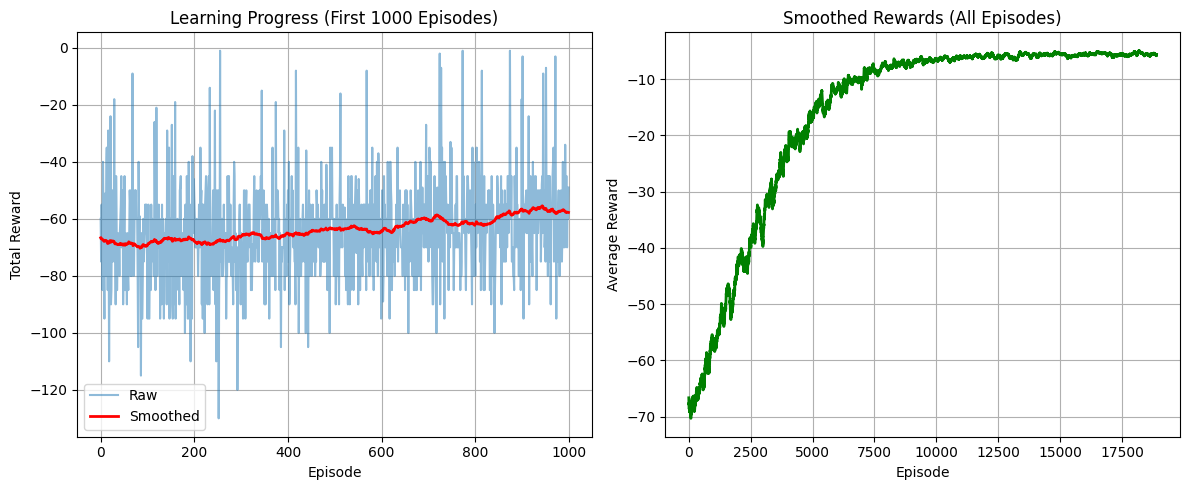

TypeError: Invalid shape (5, 5, 2, 8) for image data

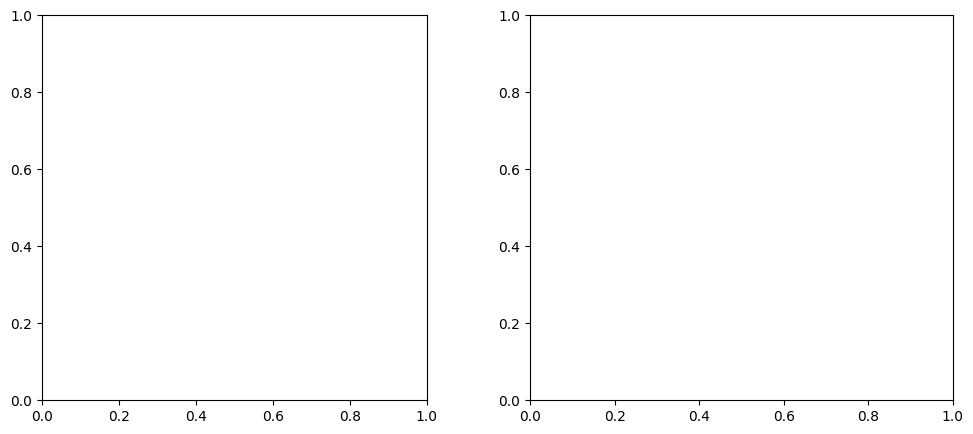

In [18]:
print("\nGenerating visualizations...")
plot_learning_progress(episode_rewards)
visualize_q_table(agent.q_table, GridConstants.MAX_EPISODES)
visualize_policy(agent, env)
print("\n" + "=" * 70)
print("ALL VISUALIZATIONS COMPLETE")
print("=" * 70)